In [88]:
import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
with zipfile.ZipFile('/content/archive (3).zip', 'r') as z:
    z.extractall('/content/dataset')

os.listdir('/content/dataset')

['business.csv', 'economy.csv', 'Clean_Dataset.csv']

In [90]:
df = pd.read_csv('/content/dataset/business.csv')
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612"
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612"
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220"
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450"
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690"


In [91]:
df.shape

(93487, 11)

In [92]:
df.dtypes

,0
date,object
airline,object
ch_code,object
num_code,int64
dep_time,object
from,object
time_taken,object
stop,object
arr_time,object
to,object


In [93]:
df.isnull().sum()

,0
date,0
airline,0
ch_code,0
num_code,0
dep_time,0
from,0
time_taken,0
stop,0
arr_time,0
to,0


## Cleaning

In [94]:
# price has commas like 1,200 so removing them first
df['price'] = df['price'].str.replace(',', '').astype(int)
df['price'].describe()

,price
count,93487.000000
mean,52540.081124
std,12969.314606
min,12000.000000
25%,45185.000000
50%,53164.000000
75%,60396.000000
max,123071.000000


In [95]:
# stop column has newlines and tabs in it
df['stop'].value_counts()

,count
stop,
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t,81489
non-stop,8102
2+-stop,1083
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IDR\n\t\t\t\t\t\t\t\t\t\t\t\t,810
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IXU\n\t\t\t\t\t\t\t\t\t\t\t\t,776
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia PAT\n\t\t\t\t\t\t\t\t\t\t\t\t,257
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Patna\n\t\t\t\t\t\t\t\t\t\t\t\t,242
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia BBI\n\t\t\t\t\t\t\t\t\t\t\t\t,152
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia STV\n\t\t\t\t\t\t\t\t\t\t\t\t,93


In [96]:
df['stop'] = df['stop'].str.replace('\n', '').str.replace('\t', '').str.strip()
df['stop'].value_counts()

,count
stop,
1-stop,81489
non-stop,8102
2+-stop,1083
1-stopVia IDR,810
1-stopVia IXU,776
1-stopVia PAT,257
1-stopVia Patna,242
1-stopVia BBI,152
1-stopVia STV,93


In [97]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

In [98]:
# time_taken is like '2h 30m', converting it to minutes
def to_minutes(t):
    try:
        parts = t.replace('h', '').replace('m', '').split()
        if len(parts) == 2:
            return int(parts[0]) * 60 + int(parts[1])
        return int(parts[0]) * 60
    except:
        return None

df['duration_mins'] = df['time_taken'].apply(to_minutes)

In [99]:
df.sample(5)

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,duration_mins
38622,2022-02-18,Vistara,UK,850,19:55,Bangalore,12h 10m,1-stop,08:05,Delhi,42521,730
57920,2022-02-21,Air India,AI,763,07:00,Kolkata,13h 00m,1-stop,20:00,Mumbai,50271,780
47165,2022-02-27,Air India,AI,808,21:00,Bangalore,17h 30m,1-stop,14:30,Kolkata,60508,1050
36907,2022-03-13,Air India,AI,679,10:25,Mumbai,05h 50m,1-stopVia IXE,16:15,Chennai,31682,350
18570,2022-02-14,Vistara,UK,970,08:45,Mumbai,02h 15m,non-stop,11:00,Delhi,55404,135


## Plots

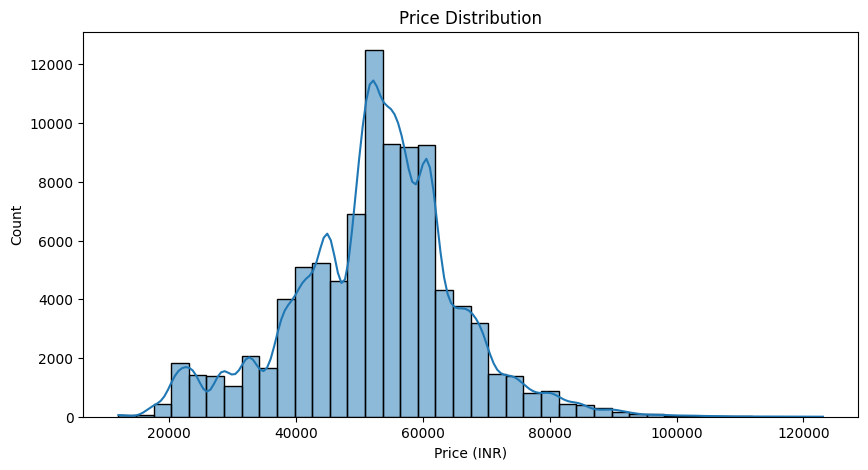

In [100]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=40, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price (INR)')
plt.show()

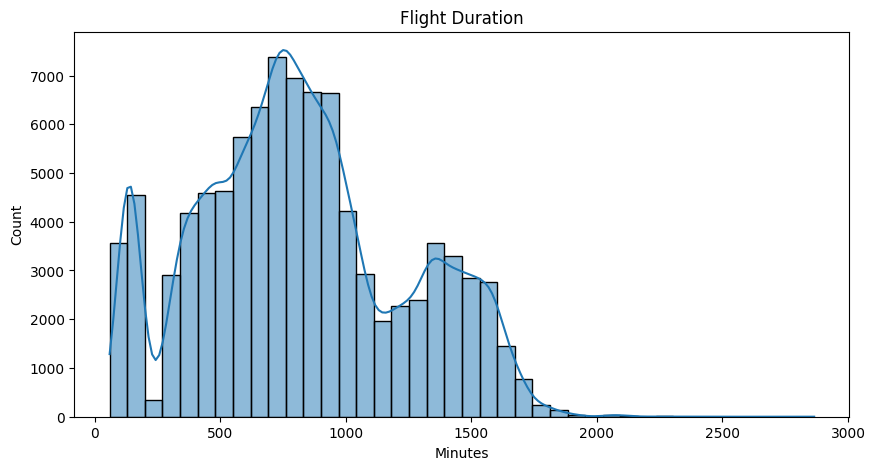

In [101]:
plt.figure(figsize=(10, 5))
sns.histplot(df['duration_mins'].dropna(), bins=40, kde=True)
plt.title('Flight Duration')
plt.xlabel('Minutes')
plt.show()

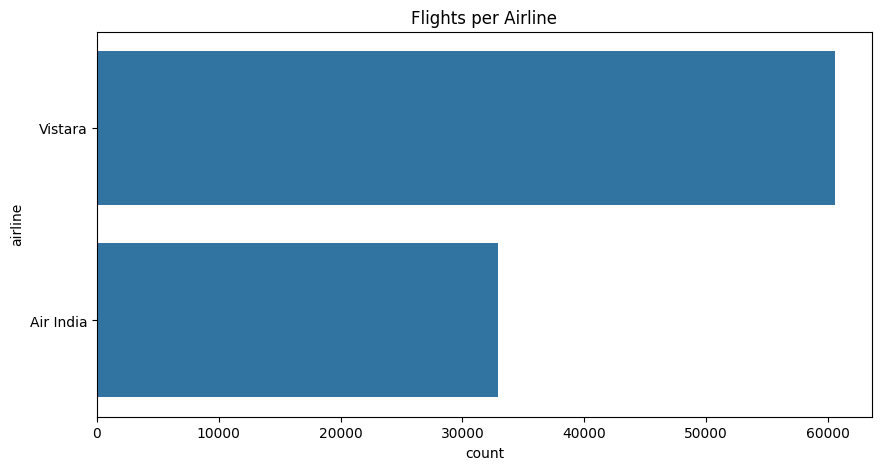

In [102]:
plt.figure(figsize=(10, 5))
order = df['airline'].value_counts().index
sns.countplot(y='airline', data=df, order=order)
plt.title('Flights per Airline')
plt.show()

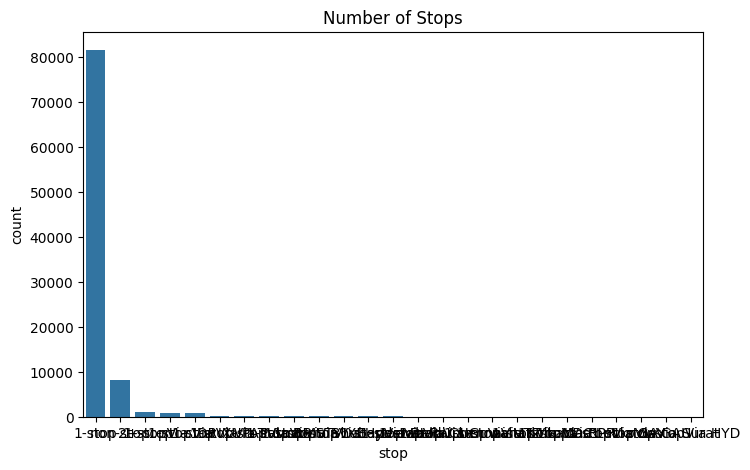

In [103]:
plt.figure(figsize=(8, 5))
order = df['stop'].value_counts().index
sns.countplot(x='stop', data=df, order=order)
plt.title('Number of Stops')
plt.show()

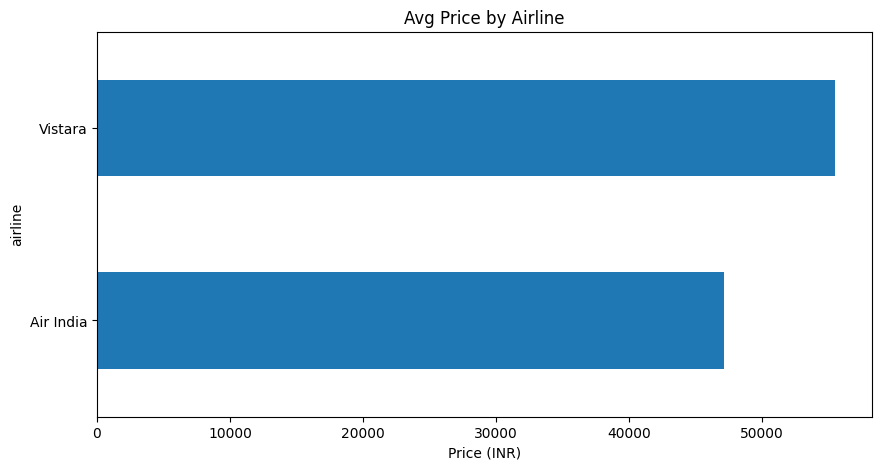

In [104]:
plt.figure(figsize=(10, 5))
df.groupby('airline')['price'].mean().sort_values().plot(kind='barh')
plt.title('Avg Price by Airline')
plt.xlabel('Price (INR)')
plt.show()

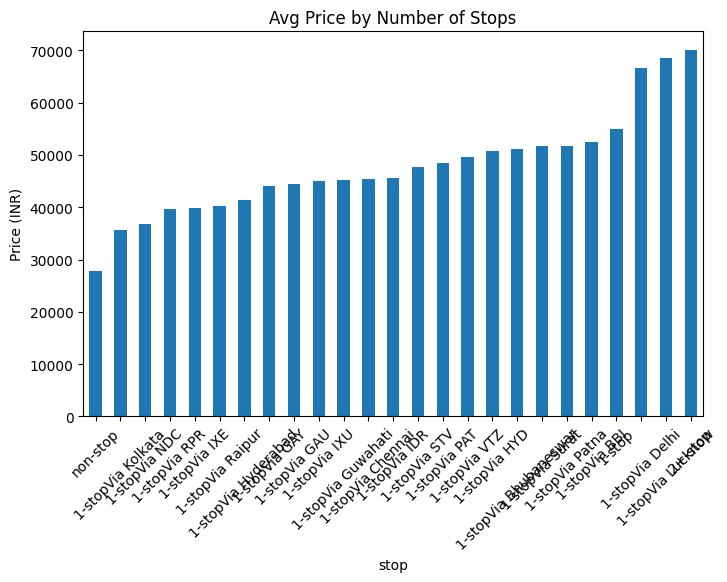

In [105]:
plt.figure(figsize=(8, 5))
df.groupby('stop')['price'].mean().sort_values().plot(kind='bar')
plt.title('Avg Price by Number of Stops')
plt.ylabel('Price (INR)')
plt.xticks(rotation=45)
plt.show()

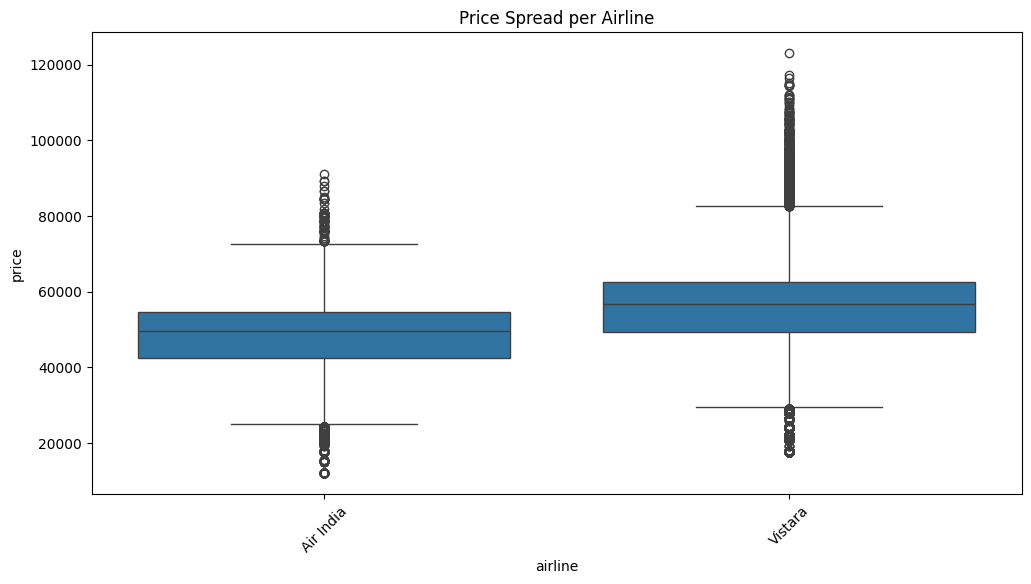

In [106]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=45)
plt.title('Price Spread per Airline')
plt.show()

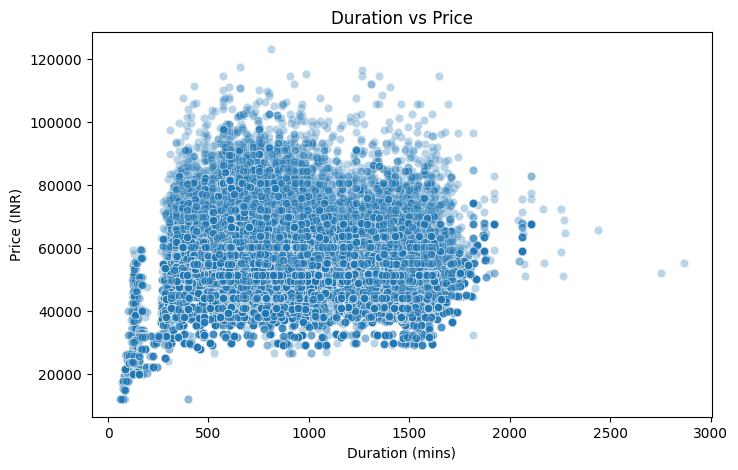

In [107]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='duration_mins', y='price', data=df, alpha=0.3)
plt.title('Duration vs Price')
plt.xlabel('Duration (mins)')
plt.ylabel('Price (INR)')
plt.show()

---
## Deeper Analysis
Using the cleaned dataset which has economy/business class, days left, source/destination cities

In [108]:
data = pd.read_csv('/content/dataset/Clean_Dataset.csv')
data.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [109]:
data.columns.tolist()

['Unnamed: 0',
 'airline',
 'flight',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class',
 'duration',
 'days_left',
 'price']

In [110]:
data.shape

(300153, 12)

### Q1 — Which airline charges the most on average?

In [111]:
data.groupby('airline')['price'].mean().sort_values(ascending=False)

,price
airline,
Vistara,30396.536302
Air_India,23507.019112
SpiceJet,6179.278881
GO_FIRST,5652.007595
Indigo,5324.216303
AirAsia,4091.072742


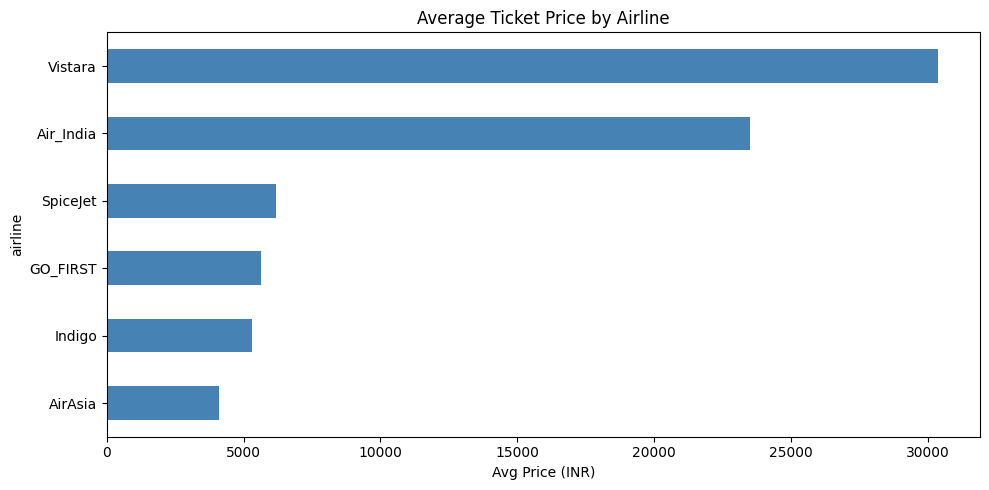

In [112]:
plt.figure(figsize=(10, 5))
data.groupby('airline')['price'].mean().sort_values().plot(kind='barh', color='steelblue')
plt.title('Average Ticket Price by Airline')
plt.xlabel('Avg Price (INR)')
plt.tight_layout()
plt.show()

### Q2 — Does booking earlier give you cheaper tickets?

In [113]:
# grouping days_left into buckets to see the trend more clearly
data['days_bucket'] = pd.cut(data['days_left'], bins=[0, 7, 15, 30, 60, 100, 200], labels=['0-7', '8-15', '16-30', '31-60', '61-100', '100+'])
data.groupby('days_bucket', observed=True)['price'].mean()

,price
days_bucket,
0-7,26451.234827
8-15,23534.110876
16-30,19754.193214
31-60,19260.919021


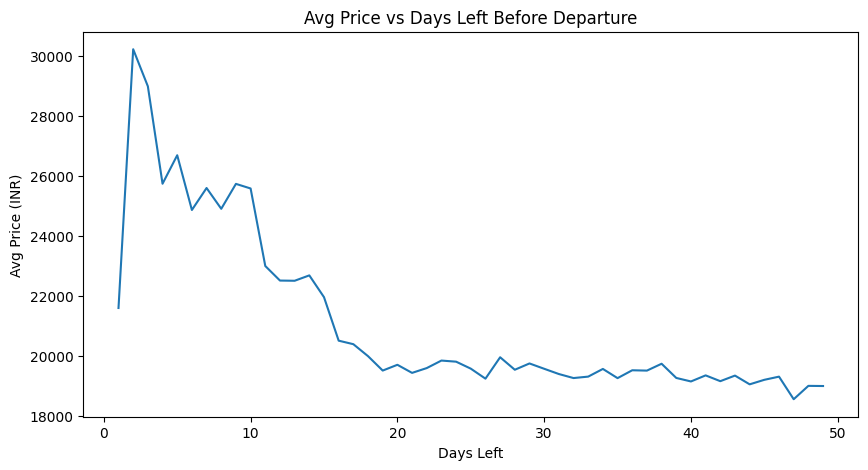

In [114]:
plt.figure(figsize=(10, 5))
data.groupby('days_left')['price'].mean().plot()
plt.title('Avg Price vs Days Left Before Departure')
plt.xlabel('Days Left')
plt.ylabel('Avg Price (INR)')
plt.show()

### Q3 — Top 5 most expensive routes

In [115]:
routes = data.groupby(['source_city', 'destination_city'])['price'].mean().reset_index()
routes.columns = ['from', 'to', 'avg_price']
routes.sort_values('avg_price', ascending=False).head(5)

,from,to,avg_price
5,Chennai,Bangalore,25081.850454
21,Kolkata,Chennai,23660.361040
3,Bangalore,Kolkata,23500.061229
0,Bangalore,Chennai,23321.850078
25,Mumbai,Bangalore,23147.873807


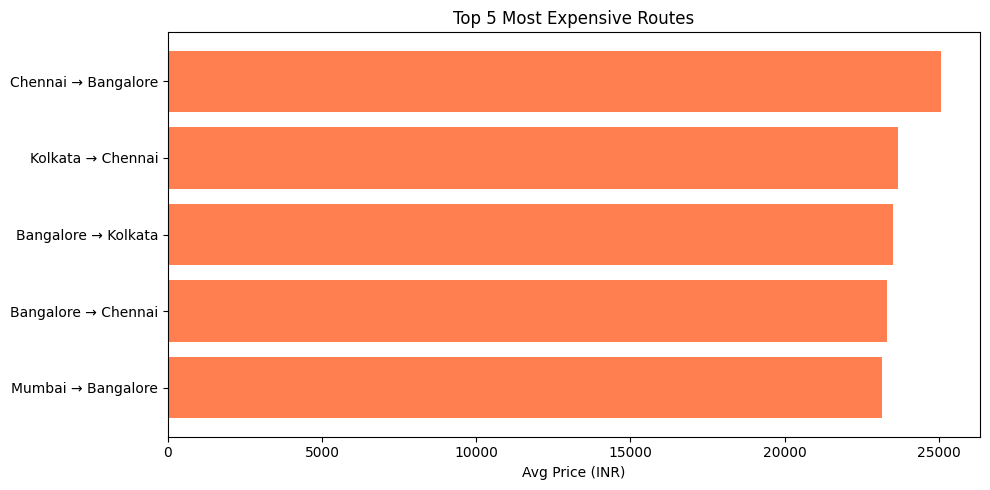

In [116]:
top5 = routes.sort_values('avg_price', ascending=False).head(5)
top5['route'] = top5['from'] + ' → ' + top5['to']

plt.figure(figsize=(10, 5))
plt.barh(top5['route'], top5['avg_price'], color='coral')
plt.title('Top 5 Most Expensive Routes')
plt.xlabel('Avg Price (INR)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Q4 — More stops = cheaper or more expensive?

In [117]:
data.groupby('stops')['price'].mean().sort_values()

,price
stops,
zero,9375.938535
two_or_more,14113.450775
one,22900.992482


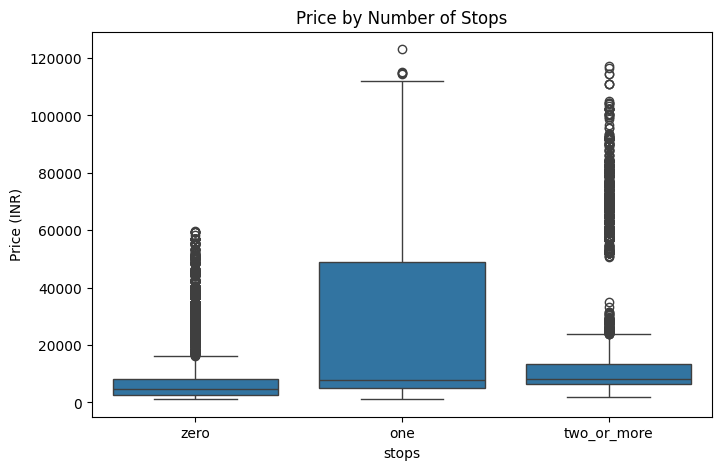

In [118]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='stops', y='price', data=data)
plt.title('Price by Number of Stops')
plt.ylabel('Price (INR)')
plt.show()

### Q5 — Economy vs Business class pricing

In [119]:
data.groupby('class')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
Business,93487.0,52540.081124,12969.314606,12000.0,45185.0,53164.0,60396.0,123071.0
Economy,206666.0,6572.342383,3743.519517,1105.0,4173.0,5772.0,7746.0,42349.0


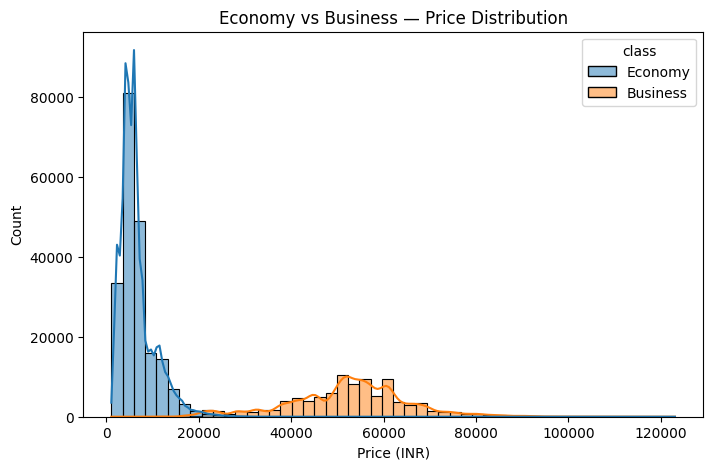

In [120]:
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='price', hue='class', bins=50, kde=True)
plt.title('Economy vs Business — Price Distribution')
plt.xlabel('Price (INR)')
plt.show()

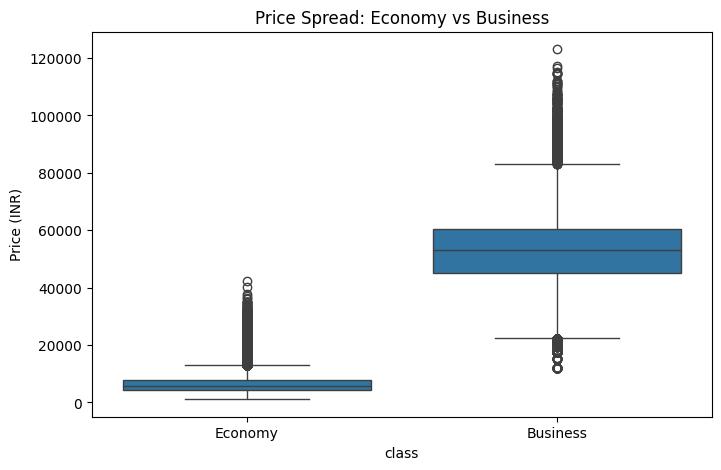

In [121]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='class', y='price', data=data)
plt.title('Price Spread: Economy vs Business')
plt.ylabel('Price (INR)')
plt.show()